# LabAst577 - Observational Astronomy
# Notebook with some basic data reduction and analysis with python

## First, import necessary libraries

In [13]:


import numpy as np
import scipy
import matplotlib.pyplot as plt
from astropy.io import fits

## Shift image to align with another

In [15]:
#First load two other images:
dir="./m57/bgsub_stacked/" 
data1 = fits.getdata(dir+'red_stacked_bgsub.fits')
data2 = fits.getdata(dir+'blue_stacked_bgsub.fits')
data3 = fits.getdata(dir+'green_stacked_bgsub.fits')
head1 = fits.getheader(dir+'red_stacked_bgsub.fits')
head2 = fits.getheader(dir+'blue_stacked_bgsub.fits')
head3 = fits.getheader(dir+'green_stacked_bgsub.fits')

In [16]:
## Obtain rough position with the mouse
pos1 = [215, 565]
pos2 = [249,493]
pos3=[226,580]


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#only': Expected package name at the start of dependency specifier
    #only
    ^


In [17]:

from photutils.centroids import centroid_com, centroid_2dg

[226.17351904 580.42078251] [263.5518941  507.84396875] [241.23802082 595.11382172]
[226.92478866 580.48479157] [263.46490752 507.89552574] [241.51581169 595.47456065]


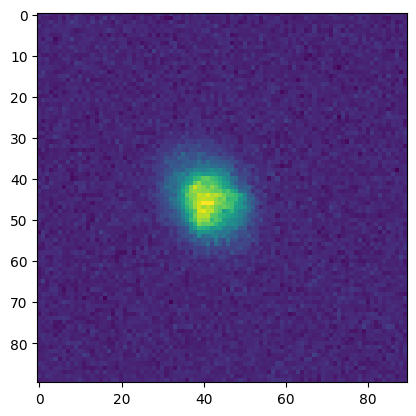

In [18]:
## Get centroid
#load centroid libraries
subdata1 = data1[pos1[1]-45:pos1[1]+45,pos1[0]-45:pos1[0]+45]#select subportion of 60x60 image
subdata2 = data2[pos2[1]-45:pos2[1]+45,pos2[0]-45:pos2[0]+45]
subdata3 = data3[pos3[1]-45:pos3[1]+45,pos3[0]-45:pos3[0]+45]#select subportion of 60x60 image
plt.imshow(subdata1)

center1,center2, center3 = centroid_2dg(subdata1)+pos1-[30,30],centroid_2dg(subdata2)+pos2-[30,30],centroid_2dg(subdata3)+pos3-[30,30]
ccenter1,ccenter2, ccenter3 = centroid_com(subdata1)+pos1-[30,30],centroid_com(subdata2)+pos2-[30,30],centroid_com(subdata3)+pos3-[30,30]
print(center1,center2, center3)
print(ccenter1,ccenter2, ccenter3)

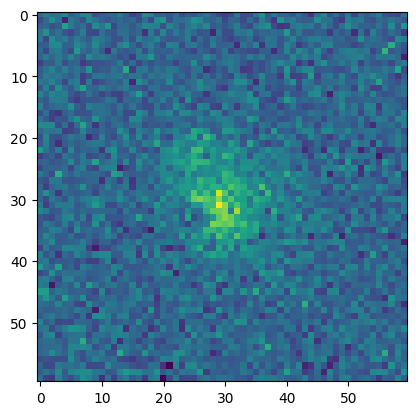

In [12]:
plt.imshow(subdata2)

In [23]:
## Shift image
shiftdat_blue = np.roll(data2,-int(np.round(center2[1]-center1[1])),axis=0) #shift in y
shiftdata2_blue = np.roll(shiftdat_blue,-int(np.round(center2[0]-center1[0])),axis=1) #shift in x

## Shift 2 image
shiftdat_green = np.roll(data3,-int(np.round(center3[1]-center1[1])),axis=0) #shift in y
shiftdata2_green = np.roll(shiftdat_green,-int(np.round(center3[0]-center1[0])),axis=1) #shift in x

Text(0.5, 1.0, 'Green Channel (Aligned)')

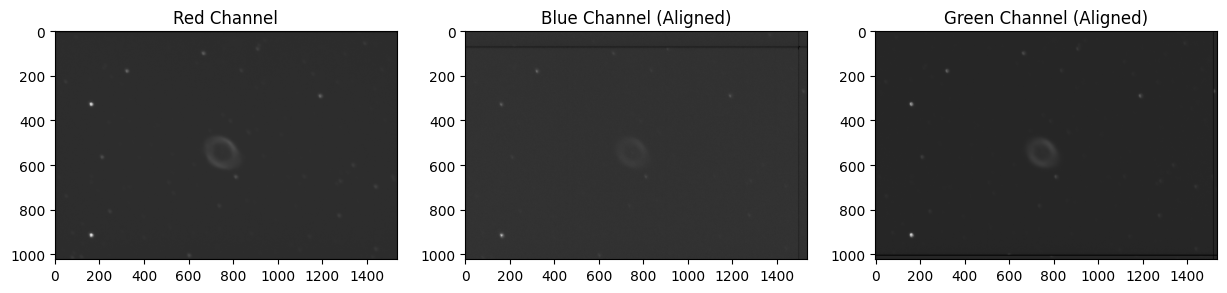

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(data1, cmap="gray")
ax1.set_title('Red Channel')
ax2.imshow(shiftdata2_blue, cmap="gray")
ax2.set_title('Blue Channel (Aligned)')
ax3.imshow(shiftdata2_green, cmap="gray")
ax3.set_title('Green Channel (Aligned)')

In [25]:
from scipy.ndimage import shift
#Shift withou roll over
shiftdat_blue=shift(data2, (-int(np.round(center2[1]-center1[1])),-int(np.round(center2[0]-center1[0]))))
shiftdat_green=shift(data3, (-int(np.round(center3[1]-center1[1])),-int(np.round(center3[0]-center1[0]))))

Text(0.5, 1.0, 'Green Channel')

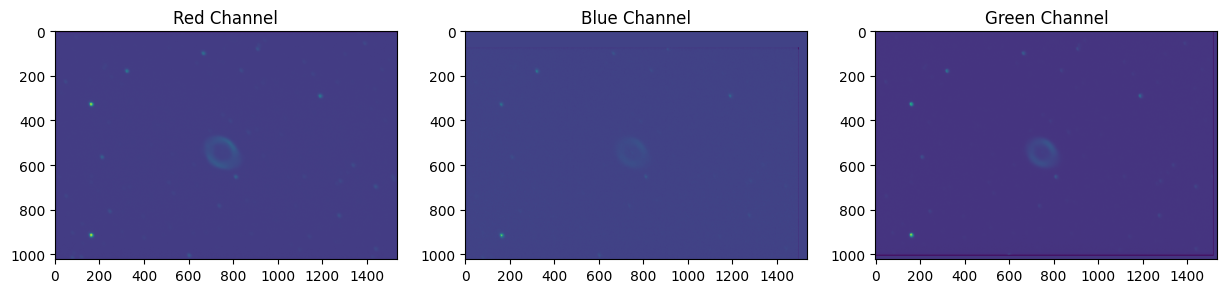

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(data1)
ax1.set_title('Red Channel')
ax2.imshow(shiftdat_blue)
ax2.set_title('Blue Channel')
ax3.imshow(shiftdat_green)
ax3.set_title('Green Channel')



In [29]:
fits.writeto("./m57/aligned/"+'blue_aligned.fits',shiftdat_blue,overwrite=True)
fits.writeto("./m57/aligned/"+'red_aligned.fits',data1,overwrite=True)
fits.writeto("./m57/aligned/"+'green_aligned.fits',shiftdat_green,overwrite=True)

PermissionError: [WinError 32] Proces nie może uzyskać dostępu do pliku, ponieważ jest on używany przez inny proces: './m57/aligned/blue_aligned.fits'

Text(0, 0.5, 'ypix')

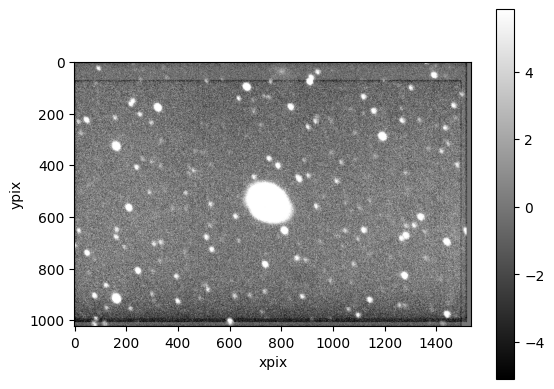

In [28]:
aligned_images=[data1,shiftdat_blue,shiftdat_green]
aligned = np.median(np.array(aligned_images), axis=0)

lo,up = np.percentile(aligned,5),np.percentile(aligned,95)
plt.figure()
plt.imshow(aligned,cmap='gray',clim=(lo,up))
plt.colorbar()
plt.xlabel('xpix')
plt.ylabel('ypix')

## Other tools

### Better alignment:
https://github.com/toros-astro/astroalign

### RGB color composite:
http://docs.astropy.org/en/stable/visualization/rgb.html

### To do aperture photometry:
https://photutils.readthedocs.io/en/stable/aperture.html

### To do PSF photometry:
https://photutils.readthedocs.io/en/stable/psf.html

### To do surface photometry:
https://photutils.readthedocs.io/en/stable/isophote.html

### To analyze time-series:
https://docs.astropy.org/en/stable/timeseries/

### On model fitting:
https://emcee.readthedocs.io/en/stable/tutorials/line/